# CNN Extreme Score Kinematics Plotter

This notebook plots $m_{jj}$ and $\Delta\eta_{jj}$ distributions for extreme CNN-score test events,
with overlays of true VBF and GGF samples.

**Usage:**
1. Set parameters in Cell 2 (config, model path, output dir, etc.)
2. Run all cells to generate plots and statistics
3. Modify thresholds or image-case and re-run plotting cells

## 1. Imports and Setup

In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '2'
# solve the problem of "libdevice not found at ./libdevice.10.bc"
os.environ['XLA_FLAGS'] = '--xla_gpu_cuda_data_dir=/home/r10222035/.conda/envs/tf2'

In [2]:
import argparse
import json
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf

sns.set_theme(style="darkgrid", palette="deep")

print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")

2026-03-24 10:33:22.262258: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-24 10:33:22.331179: I tensorflow/core/util/port.cc:104] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.11.1
NumPy version: 1.24.2


## 2. Configuration Parameters

In [3]:
# ===== USER-CONFIGURABLE PARAMETERS =====
CONFIG_PATH = "config_files/quark_jet_2_cut_L_3000_eventCNN_pT_norm_aa_wo_product_case_5_config_01.json"
MODEL_DIR = "CNN_models/last_model_GGF_VBF_CWoLa_quark_jet_2_cut_eventCNN_L_3000_aa_wo_product_case_5_01"
H5_DIR = "../Sample/data/di-photon/quark_jet_2_cut/pre-processing"
OUTPUT_DIR = "figures/extreme_score_L3000_woPhoton_case5_notebook"

# Colors (seaborn deep classic)
VBF_COLOR = "#4C72B0"
GGF_COLOR = "#DD8452"

# Thresholds and options
EXTREME_FRAC = 0.20  # Top/bottom 20%
BATCH_SIZE = 512
IMAGE_CASE = None  # None = auto-infer from config, or override with 0-5
SEED_OVERRIDE = None  # None = use config seed

print(f"Config: {CONFIG_PATH}")
print(f"Model: {MODEL_DIR}")
print(f"Output dir: {OUTPUT_DIR}")

Config: config_files/quark_jet_2_cut_L_3000_eventCNN_pT_norm_aa_wo_product_case_5_config_01.json
Model: CNN_models/last_model_GGF_VBF_CWoLa_quark_jet_2_cut_eventCNN_L_3000_aa_wo_product_case_5_01
Output dir: figures/extreme_score_L3000_woPhoton_case5_notebook


## 3. Helper Functions (from plot_extreme_score_kinematics.py)

In [4]:
def pixelization(pts, etas, phis, res=40):
    """Pixelize particle tracks into 2D histograms."""
    nevent = pts.shape[0]
    bins_eta = np.linspace(-5.0, 5.0, res + 1)
    bins_phi = np.linspace(-np.pi, np.pi, res + 1)

    bin_idx_eta = np.digitize(etas, bins_eta) - 1
    bin_idx_phi = np.digitize(phis, bins_phi) - 1

    hp_t = np.zeros((nevent, res + 1, res + 1), dtype=np.float32)
    np.add.at(hp_t, (np.arange(nevent)[:, None], bin_idx_eta, bin_idx_phi), pts)
    return hp_t[:, :res, :res]


def pt_normalization(x):
    """Per-event pT normalization."""
    mean = np.mean(x, axis=(1, 2), keepdims=True)
    std = np.std(x, axis=(1, 2), keepdims=True)
    std = np.where(std < 1e-8, 1e-8, std)
    return (x - mean) / std


def pick_rows(dataset, indices):
    """Reorder dataset rows according to indices, preserving original order."""
    order = np.argsort(indices)
    sorted_idx = indices[order]
    out = dataset[sorted_idx]
    inv = np.argsort(order)
    return out[inv]


def infer_image_case(path_hint):
    """Auto-detect image case from config npy_paths."""
    s = str(path_hint)
    if "remove_product_case_5" in s:
        return 5
    if "remove_photon_case_1" in s:
        return 1
    if "wo_decay_product" in s:
        return 2
    if "wo_product_case_5" in s:
        return 5
    return 0


def infer_resolution(config):
    """Extract image resolution from config npy_paths."""
    if "npy_paths" in config and len(config["npy_paths"]) > 0:
        p = Path(config["npy_paths"][0])
        token = p.name if p.name else p.parent.name
        if "x" in token:
            left = token.split("x")[0]
            if left.isdigit():
                return int(left)
    return 40


def expected_channels_from_case(image_case):
    """Expected number of channels for a given image case."""
    if image_case in (0, 3):
        return 3
    return 2


def resolve_existing_path(path_str, config_dir):
    """Resolve path from config with fallbacks for legacy layouts."""
    raw = Path(path_str)
    candidates = [raw, config_dir / raw, config_dir.parent / raw]

    if raw.name.startswith("selection_results_"):
        candidates.extend([
            raw.parent / "selection_cut_results" / raw.name,
            config_dir / ".." / "Sample" / "selection_cut_results" / raw.name,
            config_dir.parent / ".." / "Sample" / "selection_cut_results" / raw.name,
        ])

    for candidate in candidates:
        candidate = candidate.resolve()
        if candidate.exists():
            return str(candidate)

    raise FileNotFoundError(f"Could not resolve path from config: {path_str}")


def compute_nevent_in_sr_br(ggf_cutflow_file, vbf_cutflow_file, lumi, cut_type, decay_channel):
    """Compute event counts from cutflow."""
    cross_section_ggf = 54.67 * 1000.0
    cross_section_vbf = 4.278 * 1000.0

    if decay_channel == "ZZ4l":
        br = 0.0001240
    elif decay_channel == "aa":
        br = 0.00227
    else:
        raise ValueError(f"Unknown decay_channel: {decay_channel}")

    ggf_selection = np.load(ggf_cutflow_file, allow_pickle=True).item()
    vbf_selection = np.load(vbf_cutflow_file, allow_pickle=True).item()

    if cut_type != "quark_jet_2":
        raise ValueError("Currently only supports cut_type='quark_jet_2'.")

    n_ggf_sr = (
        cross_section_ggf
        * ggf_selection["cutflow_number"]["two quark jet: sig region"]
        / ggf_selection["cutflow_number"]["Total"]
        * br
        * lumi
    )
    n_ggf_br = (
        cross_section_ggf
        * ggf_selection["cutflow_number"]["two quark jet: bkg region"]
        / ggf_selection["cutflow_number"]["Total"]
        * br
        * lumi
    )
    n_vbf_sr = (
        cross_section_vbf
        * vbf_selection["cutflow_number"]["two quark jet: sig region"]
        / vbf_selection["cutflow_number"]["Total"]
        * br
        * lumi
    )
    n_vbf_br = (
        cross_section_vbf
        * vbf_selection["cutflow_number"]["two quark jet: bkg region"]
        / vbf_selection["cutflow_number"]["Total"]
        * br
        * lumi
    )

    return int(n_vbf_sr), int(n_ggf_sr), int(n_vbf_br), int(n_ggf_br)


def build_cwola_test_indices(h5_dir, n_events, seed=0, n_test=10000):
    """Reconstruct CWoLa test sample indices."""
    h5_dir = Path(h5_dir)
    files = {
        "VBF_in_SR": h5_dir / "VBF_in_SR.h5",
        "VBF_in_BR": h5_dir / "VBF_in_BR.h5",
        "GGF_in_SR": h5_dir / "GGF_in_SR.h5",
        "GGF_in_BR": h5_dir / "GGF_in_BR.h5",
    }

    sizes = {}
    for key, path in files.items():
        with h5py.File(path, "r") as f:
            sizes[key] = int(f["EVENT/type"].shape[0])

    n_vbf_sr, n_ggf_sr, n_vbf_br, n_ggf_br = n_events
    n_vbf_sr_test = int(sizes["VBF_in_SR"] / (sizes["VBF_in_SR"] + sizes["VBF_in_BR"]) * n_test)
    n_vbf_br_test = n_test - n_vbf_sr_test
    n_ggf_sr_test = int(sizes["GGF_in_SR"] / (sizes["GGF_in_SR"] + sizes["GGF_in_BR"]) * n_test)
    n_ggf_br_test = n_test - n_ggf_sr_test

    rng = np.random.default_rng(seed)
    idx_vbf_sr = rng.choice(sizes["VBF_in_SR"], n_vbf_sr + n_vbf_sr_test, replace=False)
    idx_vbf_br = rng.choice(sizes["VBF_in_BR"], n_vbf_br + n_vbf_br_test, replace=False)
    idx_ggf_sr = rng.choice(sizes["GGF_in_SR"], n_ggf_sr + n_ggf_sr_test, replace=False)
    idx_ggf_br = rng.choice(sizes["GGF_in_BR"], n_ggf_br + n_ggf_br_test, replace=False)

    return {
        "VBF_in_SR": np.asarray(idx_vbf_sr[n_vbf_sr:], dtype=np.int64),
        "VBF_in_BR": np.asarray(idx_vbf_br[n_vbf_br:], dtype=np.int64),
        "GGF_in_SR": np.asarray(idx_ggf_sr[n_ggf_sr:], dtype=np.int64),
        "GGF_in_BR": np.asarray(idx_ggf_br[n_ggf_br:], dtype=np.int64),
    }


def build_images_and_kinematics(h5_path, indices, res, image_case):
    """Load images and kinematics from HDF5."""
    with h5py.File(h5_path, "r") as f:
        tower_pt = pick_rows(f["TOWER/pt"], indices)
        tower_eta = pick_rows(f["TOWER/eta"], indices)
        tower_phi = pick_rows(f["TOWER/phi"], indices)
        track_pt = pick_rows(f["TRACK/pt"], indices)
        track_eta = pick_rows(f["TRACK/eta"], indices)
        track_phi = pick_rows(f["TRACK/phi"], indices)
        mjj = pick_rows(f["EVENT/mjj"], indices)
        deta = pick_rows(f["EVENT/deta"], indices)

        hp_t0 = pixelization(tower_pt, tower_eta, tower_phi, res)
        hp_t1 = pixelization(track_pt, track_eta, track_phi, res)

        decay_exists = ("PHOTON" in f.keys()) or ("LEPTON" in f.keys())
        if decay_exists:
            if ("PHOTON" in f.keys()) and ("LEPTON" in f.keys()):
                pt_decay = np.concatenate(
                    [pick_rows(f["PHOTON/pt"], indices), pick_rows(f["LEPTON/pt"], indices)], axis=1
                )
                eta_decay = np.concatenate(
                    [pick_rows(f["PHOTON/eta"], indices), pick_rows(f["LEPTON/eta"], indices)], axis=1
                )
                phi_decay = np.concatenate(
                    [pick_rows(f["PHOTON/phi"], indices), pick_rows(f["LEPTON/phi"], indices)], axis=1
                )
            elif "PHOTON" in f.keys():
                pt_decay = pick_rows(f["PHOTON/pt"], indices)
                eta_decay = pick_rows(f["PHOTON/eta"], indices)
                phi_decay = pick_rows(f["PHOTON/phi"], indices)
            else:
                pt_decay = pick_rows(f["LEPTON/pt"], indices)
                eta_decay = pick_rows(f["LEPTON/eta"], indices)
                phi_decay = pick_rows(f["LEPTON/phi"], indices)
            hp_t2 = pixelization(pt_decay, eta_decay, phi_decay, res)
        else:
            hp_t2 = np.zeros_like(hp_t0)

    if image_case == 0:
        x = np.stack([hp_t0, hp_t1, hp_t2], axis=-1)
    elif image_case == 1:
        x = np.stack([hp_t0 - hp_t2, hp_t1], axis=-1)
    elif image_case == 2:
        x = np.stack([hp_t0, hp_t1], axis=-1)
    elif image_case == 3:
        x = np.stack([hp_t0 - hp_t2, hp_t1, hp_t2], axis=-1)
    elif image_case == 4:
        x = np.stack([hp_t0, hp_t1 - hp_t2], axis=-1)
    elif image_case == 5:
        hp_t0 = hp_t0.copy()
        hp_t1 = hp_t1.copy()
        hp_t0[hp_t2 != 0] = 0
        hp_t1[hp_t2 != 0] = 0
        x = np.stack([hp_t0, hp_t1], axis=-1)
    else:
        raise ValueError(f"Unknown image_case={image_case}")

    return x.astype(np.float32), mjj.astype(np.float32), deta.astype(np.float32)


print("Helper functions defined.")

Helper functions defined.


## 4. Load Configuration and Prepare Data

In [5]:
# Load config
config_path = Path(CONFIG_PATH)
with open(config_path, "r") as f:
    config = json.load(f)

print(f"Config loaded: {config_path}")
print(json.dumps(config, indent=2))

# Set image case
image_case = IMAGE_CASE
if image_case is None:
    path_hint = config["npy_paths"][0] if "npy_paths" in config and len(config["npy_paths"]) > 0 else ""
    image_case = infer_image_case(path_hint)
    print(f"\nAuto-inferred image_case: {image_case}")
else:
    print(f"\nUsing provided image_case: {image_case}")

# Resolve paths
ggf_cutflow_file = resolve_existing_path(config["GGF_cutflow_file"], config_path.parent)
vbf_cutflow_file = resolve_existing_path(config["VBF_cutflow_file"], config_path.parent)
print(f"\nCutflow files resolved:")
print(f"  GGF: {ggf_cutflow_file}")
print(f"  VBF: {vbf_cutflow_file}")

# Compute event counts
n_events = compute_nevent_in_sr_br(
    ggf_cutflow_file=ggf_cutflow_file,
    vbf_cutflow_file=vbf_cutflow_file,
    lumi=config["luminosity"],
    cut_type=config["cut_type"],
    decay_channel=config["decay_channel"],
)
print(f"\nEvent counts: VBF_SR={n_events[0]}, GGF_SR={n_events[1]}, VBF_BR={n_events[2]}, GGF_BR={n_events[3]}")

Config loaded: config_files/quark_jet_2_cut_L_3000_eventCNN_pT_norm_aa_wo_product_case_5_config_01.json
{
  "npy_paths": [
    "../Sample/data/di-photon/quark_jet_2_cut/pre-processing/remove_product_case_5/40x40/"
  ],
  "seed": 123,
  "model_name": "quark_jet_2_cut_eventCNN_L_3000_aa_wo_product_case_5_01",
  "model_structure": "event-CNN",
  "training_method": "CWoLa",
  "sample_type": "quark jet: = 2, L: 3000 fb^-1, aa, w/o decay product",
  "luminosity": 3000,
  "cut_type": "quark_jet_2",
  "GGF_cutflow_file": "../Sample/selection_cut_results/selection_results_GGF_quark_jet.npy",
  "VBF_cutflow_file": "../Sample/selection_cut_results/selection_results_VBF_quark_jet.npy",
  "decay_channel": "aa"
}

Auto-inferred image_case: 5

Cutflow files resolved:
  GGF: /home/r10222035/higgs_production/Sample/selection_cut_results/selection_results_GGF_quark_jet.npy
  VBF: /home/r10222035/higgs_production/Sample/selection_cut_results/selection_results_VBF_quark_jet.npy

Event counts: VBF_SR=10228

In [6]:
# Build test indices
seed = config["seed"] if SEED_OVERRIDE is None else SEED_OVERRIDE
test_indices = build_cwola_test_indices(H5_DIR, n_events=n_events, seed=seed, n_test=10000)

print(f"Test indices built (seed={seed}):")
for key, arr in test_indices.items():
    print(f"  {key}: {arr.shape[0]} samples")

Test indices built (seed=123):
  VBF_in_SR: 8632 samples
  VBF_in_BR: 1368 samples
  GGF_in_SR: 4863 samples
  GGF_in_BR: 5137 samples


## 5. Load CNN Model and Configure

In [7]:
# Load model
model = tf.keras.models.load_model(MODEL_DIR, compile=False)
res = infer_resolution(config)
n_channels_expected = expected_channels_from_case(image_case)

print(f"Model loaded: {MODEL_DIR}")
print(f"Image resolution: {res}x{res}")
print(f"Expected channels: {n_channels_expected}")

2026-03-24 10:33:27.343013: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-24 10:33:27.955022: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1613] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22288 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:d8:00.0, compute capability: 8.6


Model loaded: CNN_models/last_model_GGF_VBF_CWoLa_quark_jet_2_cut_eventCNN_L_3000_aa_wo_product_case_5_01
Image resolution: 40x40
Expected channels: 2


## 6. Load and Prepare Test Sample

In [8]:
# Load images and kinematics from HDF5
h5_dir = Path(H5_DIR)
order = ["VBF_in_SR", "VBF_in_BR", "GGF_in_SR", "GGF_in_BR"]
process_map = {
    "VBF_in_SR": "VBF",
    "VBF_in_BR": "VBF",
    "GGF_in_SR": "GGF",
    "GGF_in_BR": "GGF",
}

x_list = []
mjj_list = []
deta_list = []
source_list = []

print("Loading HDF5 data...")
for sample in order:
    h5_path = h5_dir / f"{sample}.h5"
    x, mjj, deta = build_images_and_kinematics(
        h5_path=h5_path,
        indices=test_indices[sample],
        res=res,
        image_case=image_case,
    )
    x_list.append(x)
    mjj_list.append(mjj)
    deta_list.append(deta)
    source_list.extend([process_map[sample]] * x.shape[0])
    print(f"  {sample}: {x.shape[0]} samples")

x_test = np.concatenate(x_list, axis=0)
mjj = np.concatenate(mjj_list, axis=0)
deta = np.concatenate(deta_list, axis=0)
source = np.asarray(source_list)

print(f"\nCombined test sample:")
print(f"  x_test shape: {x_test.shape}")
print(f"  mjj shape: {mjj.shape}")
print(f"  deta shape: {deta.shape}")
print(f"  source counts: VBF={np.sum(source == 'VBF')}, GGF={np.sum(source == 'GGF')}")

if x_test.shape[-1] != n_channels_expected:
    raise ValueError(
        f"Input channel mismatch: model expects {n_channels_expected}, got {x_test.shape[-1]}. "
        f"Try adjusting IMAGE_CASE in Cell 2."
    )

Loading HDF5 data...
  VBF_in_SR: 8632 samples
  VBF_in_BR: 1368 samples
  GGF_in_SR: 4863 samples
  GGF_in_BR: 5137 samples

Combined test sample:
  x_test shape: (20000, 40, 40, 2)
  mjj shape: (20000,)
  deta shape: (20000,)
  source counts: VBF=10000, GGF=10000


## 7. Model Inference

In [9]:
# Normalize and predict
x_test_norm = pt_normalization(x_test)
print(f"Running model inference on {len(x_test)} samples...")
score = model.predict(x_test_norm, batch_size=BATCH_SIZE, verbose=1).reshape(-1)

print(f"\nScore statistics:")
print(f"  Min: {score.min():.6f}")
print(f"  Max: {score.max():.6f}")
print(f"  Mean: {score.mean():.6f}")
print(f"  Median: {np.median(score):.6f}")

Running model inference on 20000 samples...


2026-03-24 10:34:09.606133: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:428] Loaded cuDNN version 8401


26/40 [==================>...........] - ETA: 0s

2026-03-24 10:34:11.181328: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:630] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.


40/40 [==============================] - 3s 8ms/step

Score statistics:
  Min: 0.197109
  Max: 0.978690
  Mean: 0.625610
  Median: 0.633777


In [10]:
# Split into extreme groups
low_thr = float(np.quantile(score, EXTREME_FRAC))
high_thr = float(np.quantile(score, 1.0 - EXTREME_FRAC))
low_mask = score <= low_thr
high_mask = score >= high_thr
mid_mask = ~(low_mask | high_mask)

print(f"Extreme thresholds (EXTREME_FRAC={EXTREME_FRAC}):")
print(f"  High (VBF-like): score >= {high_thr:.6f}") 
print(f"    Count: {high_mask.sum()}")
print(f"  Low (GGF-like): score <= {low_thr:.6f}")
print(f"    Count: {low_mask.sum()}")
print(f"  Middle: {mid_mask.sum()}")

Extreme thresholds (EXTREME_FRAC=0.2):
  High (VBF-like): score >= 0.788144
    Count: 4000
  Low (GGF-like): score <= 0.463062
    Count: 4000
  Middle: 12000


In [11]:
# Save results to CSV
out_dir = Path(OUTPUT_DIR)
out_dir.mkdir(parents=True, exist_ok=True)

df = pd.DataFrame(
    {
        "score": score,
        "mjj": mjj,
        "deta_jj": deta,
        "process": source,
        "group": np.where(
            high_mask,
            "Highly VBF-like",
            np.where(low_mask, "Highly GGF-like", "Middle"),
        ),
    }
)

csv_path = out_dir / "test_scores_kinematics.csv"
df.to_csv(csv_path, index=False)
print(f"Data saved to {csv_path}")
print(f"\nHead of data:")
print(df.head())

Data saved to figures/extreme_score_L3000_woPhoton_case5_notebook/test_scores_kinematics.csv

Head of data:
      score          mjj   deta_jj process            group
0  0.844961   899.130920  5.120872     VBF  Highly VBF-like
1  0.793368   394.655914  2.655283     VBF  Highly VBF-like
2  0.661861   133.626114  1.990932     VBF           Middle
3  0.832797  1523.336304  6.658879     VBF  Highly VBF-like
4  0.814638   491.279022  4.166724     VBF  Highly VBF-like


## 8. Plotting (Two Separate Figures)

In [12]:
# Prepare binning and truth masks
n_bins = 25
bins_mjj = np.linspace(np.percentile(mjj, 1), np.percentile(mjj, 99), n_bins + 1)
bins_deta = np.linspace(np.percentile(deta, 1), np.percentile(deta, 99), n_bins + 1)

true_vbf_mask = source == "VBF"
true_ggf_mask = source == "GGF"

print(f"Binning:")
print(f"  mjj: {bins_mjj.min():.2f} - {bins_mjj.max():.2f} ({n_bins} bins)")
print(f"  deta: {bins_deta.min():.4f} - {bins_deta.max():.4f} ({n_bins} bins)")
print(f"\nMasks:")
print(f"  true VBF: {true_vbf_mask.sum()} samples")
print(f"  true GGF: {true_ggf_mask.sum()} samples")

Binning:
  mjj: 29.73 - 2649.97 (25 bins)
  deta: 0.0585 - 7.4090 (25 bins)

Masks:
  true VBF: 10000 samples
  true GGF: 10000 samples


Saved: figures/extreme_score_L3000_woPhoton_case5_notebook/extreme_score_mjj.pdf


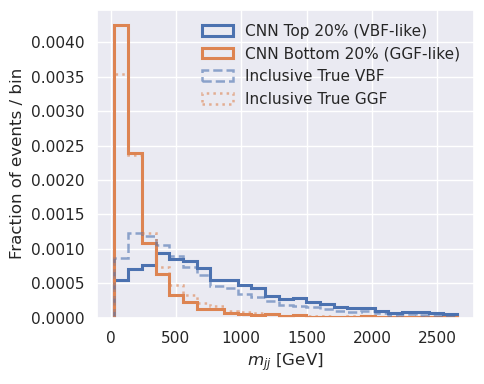

In [13]:
# Plot mjj distribution
fig_mjj, ax_mjj = plt.subplots(1, 1, figsize=(5, 4))

ax_mjj.hist(
    mjj[high_mask],
    bins=bins_mjj,
    density=True,
    histtype="step",
    linewidth=2.2,
    label="CNN Top 20% (VBF-like)",
    color=VBF_COLOR,
    )
ax_mjj.hist(
    mjj[low_mask],
    bins=bins_mjj,
    density=True,
    histtype="step",
    linewidth=2.2,
    label="CNN Bottom 20% (GGF-like)",
    color=GGF_COLOR,
    )
ax_mjj.hist(
    mjj[true_vbf_mask],
    bins=bins_mjj,
    density=True,
    histtype="step",
    linewidth=1.8,
    linestyle="--",
    label="Inclusive True VBF",
    color=VBF_COLOR,
    alpha=0.6,
    )
ax_mjj.hist(
    mjj[true_ggf_mask],
    bins=bins_mjj,
    density=True,
    histtype="step",
    linewidth=1.8,
    linestyle=":",
    label="Inclusive True GGF",
    color=GGF_COLOR,
    alpha=0.6,
    )

ax_mjj.set_xlabel(r"$m_{jj}$ [GeV]", fontsize=12)
ax_mjj.set_ylabel("Fraction of events / bin", fontsize=12)
# ax_mjj.grid(alpha=0.25)
ax_mjj.legend(frameon=False, fontsize=11)
fig_mjj.tight_layout()

fig_mjj_path = out_dir / "extreme_score_mjj.pdf"
fig_mjj.savefig(fig_mjj_path, dpi=300)
print(f"Saved: {fig_mjj_path}")

plt.show()

Saved: figures/extreme_score_L3000_woPhoton_case5_notebook/extreme_score_deta.pdf


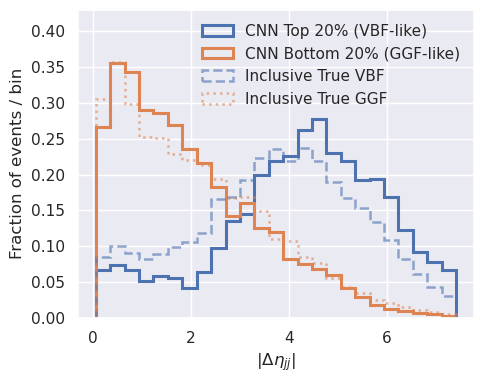

In [14]:
# Plot deta distribution
fig_deta, ax_deta = plt.subplots(1, 1, figsize=(5, 4))

ax_deta.hist(
    deta[high_mask],
    bins=bins_deta,
    density=True,
    histtype="step",
    linewidth=2.2,
    label="CNN Top 20% (VBF-like)",
    color=VBF_COLOR,
    )
ax_deta.hist(
    deta[low_mask],
    bins=bins_deta,
    density=True,
    histtype="step",
    linewidth=2.2,
    label="CNN Bottom 20% (GGF-like)",
    color=GGF_COLOR,
    )
ax_deta.hist(
    deta[true_vbf_mask],
    bins=bins_deta,
    density=True,
    histtype="step",
    linewidth=1.8,
    linestyle="--",
    label="Inclusive True VBF",
    color=VBF_COLOR,
    alpha=0.6,
    )
ax_deta.hist(
    deta[true_ggf_mask],
    bins=bins_deta,
    density=True,
    histtype="step",
    linewidth=1.8,
    linestyle=":",
    label="Inclusive True GGF",
    color=GGF_COLOR,
    alpha=0.6,
    )

ax_deta.set_xlabel(r"$|\Delta\eta_{jj}|$", fontsize=12)
ax_deta.set_ylabel("Fraction of events / bin", fontsize=12)
ax_deta.set_ylim(0, 0.43)
# ax_deta.grid(alpha=0.25)
ax_deta.legend(frameon=False, fontsize=11)
fig_deta.tight_layout()

fig_deta_path = out_dir / "extreme_score_deta.pdf"
fig_deta.savefig(fig_deta_path, dpi=300)
print(f"Saved: {fig_deta_path}")

plt.show()

## 9. Summary Statistics

In [15]:
print("=" * 50)
print("EXECUTION SUMMARY")
print("=" * 50)
print(f"\nConfiguration:")
print(f"  Config file: {CONFIG_PATH}")
print(f"  Model: {MODEL_DIR}")
print(f"  Luminosity: {config['luminosity']} fb^-1")
print(f"  Decay channel: {config['decay_channel']}")
print(f"  Image case: {image_case}")
print(f"  Resolution: {res}x{res}")
print(f"  Channels: {n_channels_expected}")

print(f"\nSample Composition:")
print(f"  Total test events: {len(df)}")
print(f"  Highly VBF-like: {high_mask.sum()} (score >= {high_thr:.5f})")
print(f"  Highly GGF-like: {low_mask.sum()} (score <= {low_thr:.5f})")
print(f"  Middle: {mid_mask.sum()}")
print(f"  True VBF: {true_vbf_mask.sum()}")
print(f"  True GGF: {true_ggf_mask.sum()}")

print(f"\nKinematics (Full Sample):")
print(f"  mjj: {mjj.min():.2f} - {mjj.max():.2f} GeV (mean={mjj.mean():.2f})")
print(f"  deta: {deta.min():.4f} - {deta.max():.4f} (mean={deta.mean():.4f})")

print(f"\nOutput Files:")
print(f"  CSV data: {csv_path}")
print(f"  mjj plot: {fig_mjj_path}")
print(f"  deta plot: {fig_deta_path}")
print(f"\n" + "=" * 50)

EXECUTION SUMMARY

Configuration:
  Config file: config_files/quark_jet_2_cut_L_3000_eventCNN_pT_norm_aa_wo_product_case_5_config_01.json
  Model: CNN_models/last_model_GGF_VBF_CWoLa_quark_jet_2_cut_eventCNN_L_3000_aa_wo_product_case_5_01
  Luminosity: 3000 fb^-1
  Decay channel: aa
  Image case: 5
  Resolution: 40x40
  Channels: 2

Sample Composition:
  Total test events: 20000
  Highly VBF-like: 4000 (score >= 0.78814)
  Highly GGF-like: 4000 (score <= 0.46306)
  Middle: 12000
  True VBF: 10000
  True GGF: 10000

Kinematics (Full Sample):
  mjj: 14.36 - 5573.96 GeV (mean=493.57)
  deta: 0.0002 - 9.2254 (mean=2.9308)

Output Files:
  CSV data: figures/extreme_score_L3000_woPhoton_case5_notebook/test_scores_kinematics.csv
  mjj plot: figures/extreme_score_L3000_woPhoton_case5_notebook/extreme_score_mjj.pdf
  deta plot: figures/extreme_score_L3000_woPhoton_case5_notebook/extreme_score_deta.pdf

